In [2]:
!pip install nltk
!pip install Sastrawi
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import re
import emoji
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import nltk

In [5]:
data1 = 'instagram (1).csv'
data2 = 'instagram (2).csv'
data3 = 'instagram (3).csv'
data4 = 'instagram (4).csv'
data5 = 'instagram (5).csv'
df1 = pd.read_csv(data1)
df2 = pd.read_csv(data2)
df3 = pd.read_csv(data3)
df4 = pd.read_csv(data4)
df5 = pd.read_csv(data5)


In [6]:
df1.sample(5)

,user,komen,tanggal komentar,likes
47,uaaaheeemmm,"Maaf blm bisa membantu dengan dana, cuma bisa ...",1w,Reply
8,nastain05,"- Cukup Satu Kalimat Aja Cania "" MARI BANTU BE...",1w,1 like
82,wardah.polem,🙌🔥,1w,Reply
49,adisptraa_4,Kok kode QR gagal ya,1w,Reply
22,fransermo,"Negara Andalas, keren juga namanya.",1w,10 likes


In [7]:
df2.sample(5)

,user,komen,tanggal komentar,likes
163,chanyeolabhi22,NaN,2d,Reply
16,kuliahsaham,❤️,1w,31 likes
961,ergy.wirawann,Barakallahu fiik,1w,Reply
136,hani.stfu,"yng di sana harusnya malu, tapi sayangnya udah...",1d,Reply
139,fie_elarief,"Semangat bang, semangat semua yg kita lakukan ...",1d,Reply


In [8]:
df3.sample(5)

,user,komen,tanggal komen,likes
864,fokusindiri,Hanya 31 hari🔥🔥,1w,Reply
579,atz_baday,Alhamdulillah . Sesama rakyat emang harus pedu...,1w,Reply
237,thasyakevin,Gokiiillll bang🔥🔥🔥🔥🔥,6d,Reply
324,xiao25456,Jangan di kasih ke pemerintah nanti di olah bn...,1w,Reply
421,xmgprltm,"12 jam 5,8 m🔥🔥",1w,Reply


In [9]:
df4.sample(5)

,user,komen,tanggal komen,likes
359,danes_anggoro_official,Sehat terus bang. Allah bless you,2d,Reply
505,fajarwidyanto,"Masyaa Allah, Alhamdulillah. Rakyat bantu rakyat",2d,Reply
114,nurma_yunitanita,Hujan deras lagi di medan looo weee 😭😭😭🙏🙏🙏,2h,Reply
563,enterpreuner72,"Jgn lewat pemerintah kak, udah bobrok bnget , ...",2d,Reply
759,huzzem,MasyaAllah TabarakaAllah,3d,Reply


In [10]:
df5.sample(5)

,user,komen,tanggal komen,likes
252,raihaanlubis,rispek,1w,Reply
619,rynfhnzk,بارك الله,1w,Reply
561,imjoyaa_,Bang kalo ke aceh tamiang tolong ke pedalaman ...,1w,Reply
384,iedha_zhair,Langsung ke orgnya ...jgn di titip2,1w,Reply
213,bettokaw212,Mantap bang gasss langsung salurkan jangan le...,1w,Reply


In [11]:
# Mengecek jumlah row & coloumn
print(f'shape data1 : {df1.shape}')
print(f'shape data2 : {df2.shape}')
print(f'shape data3 : {df3.shape}')
print(f'shape data4 : {df4.shape}')
print(f'shape data5 : {df5.shape}')

shape data1 : (139, 4)
shape data2 : (1058, 4)
shape data3 : (1050, 4)
shape data4 : (1023, 4)
shape data5 : (986, 4)


**GABUNGIN 5 DATA**

In [12]:
import pandas as pd

# Baca kedua file
df1 = pd.read_csv('instagram (1).csv')
df2 = pd.read_csv('instagram (2).csv')
df3 = pd.read_csv('instagram (3).csv')
df4 = pd.read_csv('instagram (4).csv')
df5 = pd.read_csv('instagram (5).csv')

# Gabungkan secara vertikal
df_gabung = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

# Simpan hasil (opsional)
df_gabung.to_csv('data_gabungan.csv', index=False)

In [13]:
data_path = 'data_gabungan.csv'
df = pd.read_csv(data_path)

In [17]:
# Jika df_gabung adalah DataFrame hasil penggabungan
jumlah_baris = len(df_gabung)
# atau
jumlah_baris, jumlah_kolom = df_gabung.shape

print(f"Jumlah baris setelah digabung: {jumlah_baris}")
print(f"Jumlah kolom: {jumlah_kolom}")

Jumlah baris setelah digabung: 4256
Jumlah kolom: 5


**BERSIHKAN DATA YG MASIH BELUM RAPI (SESUAIKAN DENGAN KOMENTAR YG ADA**

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4256 entries, 0 to 4255
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   user              4256 non-null   object
 1   komen             4138 non-null   object
 2   tanggal komentar  1197 non-null   object
 3   likes             4256 non-null   object
 4   tanggal komen     3059 non-null   object
dtypes: object(5)
memory usage: 166.4+ KB


In [40]:
import pandas as pd

# Baca dataset (ganti nama file sesuai kebutuhan)
df = pd.read_csv('data_gabungan.csv')  # ← pastikan file ini ada!

# Cek jumlah baris sebelum
print(f"Jumlah baris SEBELUM cleaning: {len(df)}")

# Hapus baris yang NaN di kolom 'cleaned_komen'
df_clean = df.dropna(subset=['komen'])

# Hapus baris yang string kosong atau hanya spasi
df_clean = df_clean[df_clean['komen'].str.strip().astype(str) != '']

# Cek jumlah baris setelah
print(f"Jumlah baris SETELAH cleaning: {len(df_clean)}")
print(f"Jumlah baris yang dihapus: {len(df) - len(df_clean)}")

# Simpan hasil
df_clean.to_csv('data_gabungan_cleaned.csv', index=False)

# Tampilkan contoh
print("\nContoh data setelah cleaning:")
print(df_clean.head(100))

Jumlah baris SEBELUM cleaning: 4256
Jumlah baris SETELAH cleaning: 4138
Jumlah baris yang dihapus: 118

Contoh data setelah cleaning:
               user                                              komen  \
0         yosuandre                                                ❤️🤍   
1      blocknews.id                                                 🔥🔥   
2      irwandiferry                                           letsgooo   
3         ridha4you  Bahan makanan Naik Berkali-kali lipat dan peme...   
4    yusdin_ibrahim                                       Semangat bg🙌   
..              ...                                                ...   
98      irpanarwii_                                Coki 1-0 pemerintah   
99      herlina0105  Puji Tuhan, kiranya yang sedikit ini bisa memb...   
100    andi_kuswadi                    nomer rekening nya ada ga bang?   
101    irfanndk_666                         dari rakyat untuk rakyat 🙌   
102         hbibly2  BBM di tempat kami bener bener 

**HAPUS DUPLICATE 'USER'**

In [42]:
# Cek jumlah nilai duplikat di kolom 'user'
duplicates = df['user'].duplicated(keep=False)  # semua duplikat (termasuk yang pertama)
print(f"Jumlah baris dengan nilai duplikat di 'user': {duplicates.sum()}")

# Tampilkan contoh duplikat
print("\nContoh baris dengan nilai duplikat:")
print(df[duplicates].head(10))

Jumlah baris dengan nilai duplikat di 'user': 407

Contoh baris dengan nilai duplikat:
              user                                              komen  \
0        yosuandre                                                ❤️🤍   
1     blocknews.id                                                 🔥🔥   
2     irwandiferry                                           letsgooo   
4   yusdin_ibrahim                                       Semangat bg🙌   
5       henndraaa1   Dari Rakyat Untuk Rakyat,Semoga Lekas Membaik...   
7         asfianss                      Gw liat ad yg donasi 100 juta   
9         qemocenx  Pasukan elite BANSER kemana nih..dulu teriak2 ...   
10       fransermo                Negara Andalas, keren juga namanya.   
11  nanasojol_shop  Bismillah🔥 maaf bang cuma bisa donasi semampu ...   
12         njimint                             donasi pakaian ada gak   

        likes tanggal komen tanggal_absolut  
0     4 likes           NaN      2025-12-02  
1     5 likes    

In [43]:
# Baca data
df = pd.read_csv('data_gabungan_cleaned.csv')

# Hapus duplikat berdasarkan kolom 'akun' — simpan baris pertama
df_clean = df.drop_duplicates(subset=['user'], keep='first')

# Tampilkan info
print(f"Sebelum: {len(df)} baris")
print(f"Sesudah: {len(df_clean)} baris")
print(f"Jumlah duplikat dihapus: {len(df) - len(df_clean)}")

# Simpan hasil
df_clean.to_csv('cleaning duplicate instagram.csv', index=False)

Sebelum: 4138 baris
Sesudah: 3904 baris
Jumlah duplikat dihapus: 234


**BENERIN TANGGAL KOMEN**

In [45]:
import pandas as pd
from datetime import datetime, timedelta
import re

# Baca data
df = pd.read_csv('cleaning duplicate instagram.csv')

# Referensi: 12 Desember 2025 pukul 08:30
reference_datetime = datetime(2025, 12, 12, 8, 30)

def convert_relative_time(time_str):
    if pd.isna(time_str) or not isinstance(time_str, str):
        return 'Invalid Date'
    try:
        s = time_str.strip().lower()
        match = re.match(r'^(\d+)\s*([hd])$', s)
        if not match:
            return 'Invalid Date'
        number = int(match.group(1))
        unit = match.group(2)
        if unit == 'h':
            dt = reference_datetime - timedelta(hours=number)
        elif unit == 'd':
            dt = reference_datetime - timedelta(days=number)
        elif unit == 'w':
            dt = reference_datetime - timedelta(weeks=number)
        else:
            return 'Invalid Date'
        return dt.strftime('%Y-%m-%d')
    except:
        return 'Invalid Date'

# Konversi
df['tanggal_absolut'] = df['tanggal komentar'].apply(convert_relative_time)

# Ganti 'Invalid Date' (opsional)
df['tanggal_absolut'] = df['tanggal_absolut'].replace('Invalid Date', '2025-12-02')

# 🔥 HAPUS KOLOM ASLI 'waktu'
df = df.drop(columns=['tanggal komentar'])

# Simpan
df.to_csv('instagram_preprocessed_waktu.csv', index=False)

# Menampilkan beberapa hasil untuk verifikasi
print("Sample of preprocessed data:")
print(df.head(100))

Sample of preprocessed data:
              user                                              komen  \
0        yosuandre                                                ❤️🤍   
1     blocknews.id                                                 🔥🔥   
2     irwandiferry                                           letsgooo   
3        ridha4you  Bahan makanan Naik Berkali-kali lipat dan peme...   
4   yusdin_ibrahim                                       Semangat bg🙌   
..             ...                                                ...   
95    rizki_haloka  Bang tapteng dan tapsell jgn lupakan yaa !!! S...   
96  charleesantyka                       Cok, elu sumbang berapa?????   
97        dennakaa                                               gass   
98        _wawan_0                                     Thanks bang  👏   
99   muhammasibthi                              belum punya uangg 😭😭😭   

        likes tanggal komen tanggal_absolut  
0     4 likes           NaN      2025-12-02  
1 

**BENERIN JUMLAH LIKE/VIEW**

In [46]:
import pandas as pd
import re

# Baca dataset (ganti nama file sesuai kebutuhan)
df = pd.read_csv('instagram_preprocessed_waktu.csv')  # ← pastikan file ini ada!

def convert_likes(likes_str):
    if pd.isna(likes_str) or not isinstance(likes_str, str):
        return 0

    print(f"Processing: '{likes_str}'")

    try:
        # Normalisasi: lowercase dan strip spasi
        s = likes_str.strip().lower()

        # Hapus kata 'likes' atau 'like'
        s = re.sub(r'\s*likes?\s*', '', s).strip()

        # Jika masih ada koma, ganti dengan titik (jika koma digunakan sebagai desimal)
        # Tapi untuk "1,038", kita ingin hapus koma (pemisah ribuan)
        if ',' in s and '.' not in s:
            # Asumsikan koma adalah pemisah ribuan → hapus semua koma
            s = s.replace(',', '')
        elif ',' in s and '.' in s:
            # Ada koma dan titik — mungkin koma adalah desimal → ganti koma jadi titik
            s = s.replace(',', '.')

        # Ekstrak hanya digit dan titik (untuk angka desimal)
        cleaned = re.sub(r'[^\d.]', '', s)
        if not cleaned or cleaned == '.':
            return 0

        # Konversi ke float, lalu int
        number = int(float(cleaned))

        return number

    except Exception as e:
        print(f"Error converting '{likes_str}': {e}")
        return 0

# Terapkan ke kolom 'likes'
df['likes'] = df['likes'].apply(convert_likes)

# Simpan hasil
df.to_csv('instagram_cleaned_likes.csv', index=False)

# Tampilkan hasil
print("Sample of cleaned likes:")
print(df.head(10))

Processing: '4 likes'
Processing: '5 likes'
Processing: '193 likes'
Processing: '14 likes'
Processing: '2 likes'
Processing: '7 likes'
Processing: '33 likes'
Processing: '46 likes'
Processing: '1 like'
Processing: '1 like'
Processing: '10 likes'
Processing: '1 like'
Processing: '5 likes'
Processing: '3 likes'
Processing: '80 likes'
Processing: '1 like'
Processing: 'Reply'
Processing: '3 likes'
Processing: '1 like'
Processing: '9 likes'
Processing: '6 likes'
Processing: '4 likes'
Processing: '2 likes'
Processing: '3 likes'
Processing: '3 likes'
Processing: '205 likes'
Processing: '29 likes'
Processing: '14 likes'
Processing: '6 likes'
Processing: '1 like'
Processing: 'Reply'
Processing: 'Reply'
Processing: 'Reply'
Processing: 'Reply'
Processing: 'Reply'
Processing: 'Reply'
Processing: 'Reply'
Processing: 'Reply'
Processing: 'Reply'
Processing: 'Reply'
Processing: 'Reply'
Processing: 'Reply'
Processing: 'Reply'
Processing: 'Reply'
Processing: 'Reply'
Processing: 'Reply'
Processing: 'Repl

In [47]:
import pandas as pd

# Baca dataset
df = pd.read_csv('instagram_cleaned_likes.csv')  # ← ganti dengan nama file-mu

# Hapus kolom 'tanggal komen'
df = df.drop(columns=['tanggal komen'])

# Simpan hasil
df.to_csv('instagram_cleaned_likes1.csv', index=False)

# Tampilkan info kolom yang tersisa
print("Kolom yang tersisa:")
print(df.columns.tolist())

Kolom yang tersisa:
['user', 'komen', 'likes', 'tanggal_absolut']


**PREPOCESSING DATA (HAPUS EMOJI & KECILKAN HURUF)**

In [48]:
# Fungsi untuk menghapus emoji
def remove_emoji(text):
    if isinstance(text, str):  # Check if the text is a string before processing
        return emoji.replace_emoji(text, replace='')
    else:
        return text  # Return the original value if it's not a string

# Fungsi untuk membersihkan teks
def clean_text(text):
    # Menghapus emoji
    text = remove_emoji(text)
    # Mengubah ke huruf kecil
    if isinstance(text, str):  # Check if the text is a string before processing
        text = text.lower()
        # Menghapus username, hashtag, dan link
        text = re.sub(r'@\w+|#\w+|http\S+', '', text)
        # Menghapus angka dan tanda baca kecuali huruf
        text = re.sub(r'[^a-z\s]', '', text)
        # Menghapus spasi ekstra
        text = re.sub(r'\s+', ' ', text).strip()
    return text

# Mengaplikasikan fungsi clean_text ke kolom 'comment'
df['cleaned_komen'] = df['komen'].apply(clean_text)

# Menampilkan data yang sudah dibersihkan
print("\nData Setelah Pembersihan:")
print(df.head())


Data Setelah Pembersihan:
             user                                              komen  likes  \
0       yosuandre                                                ❤️🤍      4   
1    blocknews.id                                                 🔥🔥      5   
2    irwandiferry                                           letsgooo    193   
3       ridha4you  Bahan makanan Naik Berkali-kali lipat dan peme...     14   
4  yusdin_ibrahim                                       Semangat bg🙌      2   

  tanggal_absolut                                      cleaned_komen  
0      2025-12-02                                                     
1      2025-12-02                                                     
2      2025-12-02                                           letsgooo  
3      2025-12-02  bahan makanan naik berkalikali lipat dan pemer...  
4      2025-12-02                                        semangat bg  


**MENGHAPUS STOPWORDS**

In [49]:
# Mengunduh stopwords dan tokenizer
nltk.download('stopwords')
nltk.download('punkt')
import nltk
nltk.download('punkt_tab')

# Menghapus stop words
stop_words = set(stopwords.words('indonesian'))  # Gunakan stopwords bahasa Indonesia
df['cleaned_komen'] = df['cleaned_komen'].apply(
    lambda x: ' '.join([word for word in word_tokenize(x) if word not in stop_words]) if isinstance(x, str) else x
)

# Menampilkan data setelah penghapusan stop words
print("\nData Setelah Penghapusan Stop Words:")
print(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Data Setelah Penghapusan Stop Words:
             user                                              komen  likes  \
0       yosuandre                                                ❤️🤍      4   
1    blocknews.id                                                 🔥🔥      5   
2    irwandiferry                                           letsgooo    193   
3       ridha4you  Bahan makanan Naik Berkali-kali lipat dan peme...     14   
4  yusdin_ibrahim                                       Semangat bg🙌      2   

  tanggal_absolut                                      cleaned_komen  
0      2025-12-02                                                     
1      2025-12-02                                                     
2      2025-12-02                                           letsgooo  
3      2025-12-02  bahan makanan berkalikali lipat pemerintah lam...  
4      2025-12-02                                        semangat bg  


**STEMMING DATA**

In [50]:
# Membuat objek stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Proses stemming
df['stemmed_komen'] = df['cleaned_komen'].apply(
    lambda x: stemmer.stem(x) if isinstance(x, str) else ''
)

# Menampilkan data setelah stemming
print("\nData Setelah Stemming:")
print(df.head())


Data Setelah Stemming:
             user                                              komen  likes  \
0       yosuandre                                                ❤️🤍      4   
1    blocknews.id                                                 🔥🔥      5   
2    irwandiferry                                           letsgooo    193   
3       ridha4you  Bahan makanan Naik Berkali-kali lipat dan peme...     14   
4  yusdin_ibrahim                                       Semangat bg🙌      2   

  tanggal_absolut                                      cleaned_komen  \
0      2025-12-02                                                      
1      2025-12-02                                                      
2      2025-12-02                                           letsgooo   
3      2025-12-02  bahan makanan berkalikali lipat pemerintah lam...   
4      2025-12-02                                        semangat bg   

                                       stemmed_komen  
0            

**TOKENIZATION**

In [51]:
# Tokenisasi
df['tokens'] = df['stemmed_komen'].apply(
    lambda x: word_tokenize(x) if isinstance(x, str) else []
)

# Menampilkan data setelah tokenisasi
print("\nData Setelah Tokenisasi:")
print(df.head())

# Menyimpan data yang sudah diproses ke file baru
df.to_csv('processed_clean.csv', index=False)


Data Setelah Tokenisasi:
             user                                              komen  likes  \
0       yosuandre                                                ❤️🤍      4   
1    blocknews.id                                                 🔥🔥      5   
2    irwandiferry                                           letsgooo    193   
3       ridha4you  Bahan makanan Naik Berkali-kali lipat dan peme...     14   
4  yusdin_ibrahim                                       Semangat bg🙌      2   

  tanggal_absolut                                      cleaned_komen  \
0      2025-12-02                                                      
1      2025-12-02                                                      
2      2025-12-02                                           letsgooo   
3      2025-12-02  bahan makanan berkalikali lipat pemerintah lam...   
4      2025-12-02                                        semangat bg   

                                       stemmed_komen  \
0         

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user             3904 non-null   object
 1   komen            3904 non-null   object
 2   likes            3904 non-null   int64 
 3   tanggal_absolut  3904 non-null   object
 4   cleaned_komen    3904 non-null   object
 5   stemmed_komen    3904 non-null   object
 6   tokens           3904 non-null   object
dtypes: int64(1), object(6)
memory usage: 213.6+ KB


**BUAT VISUALISASI WORLDCLOUD**

In [54]:
from wordcloud import STOPWORDS

# Tambahkan kata khusus Indonesia yang mungkin tidak ada di daftar bawaan
stop_words = set(STOPWORDS)
stop_words.update(['yg', 'nya', 'dgn', 'ya', 'trs', 'jg', 'kalo', 'gw', 'lu', 'gue', 'lo', 'nih', 'mah', 'sih', 'krn', 'karena'])

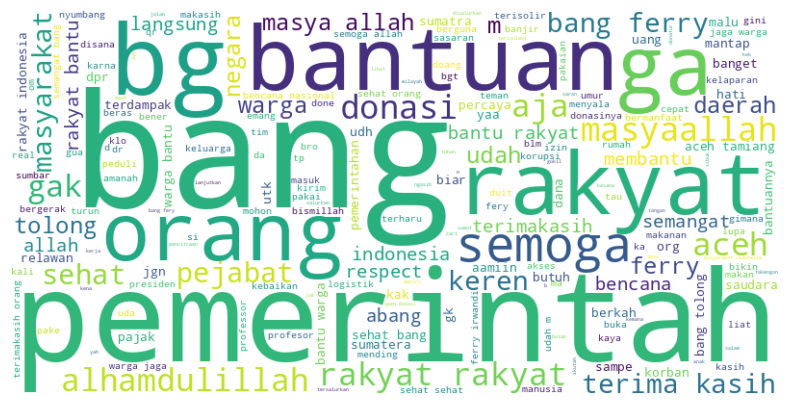

In [57]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Memuat data dari file CSV
df = pd.read_csv('processed_clean.csv')  # Ganti 'path_to_your_file.csv' dengan jalur file data Anda

# Gabungkan semua teks dalam kolom 'cleaned_komen' menjadi satu string besar
text = " ".join(judul for judul in df['cleaned_komen'].dropna())  # Pastikan tidak ada nilai NaN



# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Remove axis
plt.show()

**VISUALISASI KATA KUNCI TERBANYAK (WORDCLOUD)**

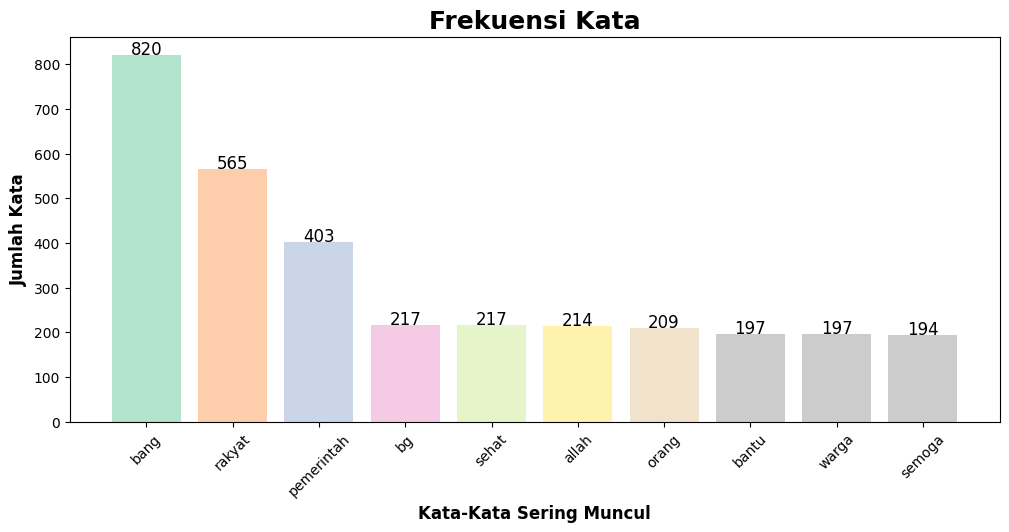

In [58]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

text = " ".join(judul for judul in df['cleaned_komen'].dropna())


tokens = [word for word in text.split() if word not in stop_words]
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)

# Menggunakan palet warna lebih soft
colors = plt.cm.Pastel2(range(len(word)))

# Membuat plot
plt.figure(figsize=(12, 5))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 1.6 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')

# Menampilkan plot
plt.show()

In [90]:
label_count = df[''].value_counts()
label_count

,count
label,
Netral,1531
Positif,1105
Negatif,604


**LABELING DATA (POSITIF, NEGATIF, NETRAL) LEXICON BASED**

In [59]:
# Unduh kamus leksikon positif dan negatif dari GITHUB
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep='\t', header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep='\t', header=None)[0])

# Fungsi untuk menentukan sentimen dan menghitung skornya
def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count

        if sentiment_score > 0:
            sentiment = "Positif"
        elif sentiment_score < 0:
            sentiment = "Negatif"
        else:
            sentiment = "Netral"
        return sentiment_score, sentiment
    return 0, "Netral"

In [62]:
# Tentukan sentimen dan skor untuk setiap ulasan
df[['Score', 'label']] = df['stemmed_komen'].apply(lambda x: pd.Series(determine_sentiment(x)))

# Tampilkan hasilnya
df.head(10)

,user,komen,likes,tanggal_absolut,cleaned_komen,stemmed_komen,tokens,Score,label
0,yosuandre,❤️🤍,4,2025-12-02,NaN,NaN,[],0,Netral
1,blocknews.id,🔥🔥,5,2025-12-02,NaN,NaN,[],0,Netral
2,irwandiferry,letsgooo,193,2025-12-02,letsgooo,letsgooo,['letsgooo'],0,Netral
3,ridha4you,Bahan makanan Naik Berkali-kali lipat dan peme...,14,2025-12-02,bahan makanan berkalikali lipat pemerintah lam...,bahan makan berkalikali lipat perintah lambat ...,"['bahan', 'makan', 'berkalikali', 'lipat', 'pe...",1,Positif
4,yusdin_ibrahim,Semangat bg🙌,2,2025-12-02,semangat bg,semangat bg,"['semangat', 'bg']",0,Netral
5,henndraaa1,"Dari Rakyat Untuk Rakyat,Semoga Lekas Membaik...",7,2025-12-02,rakyat rakyatsemoga lekas membaik,rakyat rakyatsemoga lekas baik,"['rakyat', 'rakyatsemoga', 'lekas', 'baik']",0,Netral
6,urangpurwakarta.id,Semangat guys hayu saling bantu 🔥,33,2025-12-02,semangat guys hayu bantu,semangat guys hayu bantu,"['semangat', 'guys', 'hayu', 'bantu']",1,Positif
7,asfianss,Gw liat ad yg donasi 100 juta,46,2025-12-02,gw liat ad yg donasi juta,gw liat ad yg donasi juta,"['gw', 'liat', 'ad', 'yg', 'donasi', 'juta']",1,Positif
8,nastain05,"- Cukup Satu Kalimat Aja Cania "" MARI BANTU BE...",1,2025-12-02,kalimat aja cania mari bantu kebiasaan bikin l...,kalimat aja cania mari bantu biasa bikin lagu ...,"['kalimat', 'aja', 'cania', 'mari', 'bantu', '...",1,Positif
9,qemocenx,Pasukan elite BANSER kemana nih..dulu teriak2 ...,1,2025-12-02,pasukan elite banser kemana nihdulu teriak bub...,pasu elite banser mana nihdulu teriak bubarin ...,"['pasu', 'elite', 'banser', 'mana', 'nihdulu',...",-1,Negatif


**VISUALISASI JUMLAH SENTIMEN PUBLIK**

/tmp/ipython-input-664524484.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette="pastel")


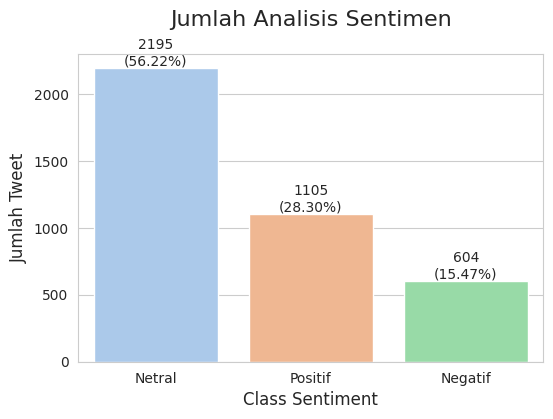

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = df['label'].value_counts()
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette="pastel")
plt.title("Jumlah Analisis Sentimen", fontsize=16, pad=20)
plt.xlabel("Class Sentiment", fontsize=12)
plt.ylabel("Jumlah Tweet", fontsize=12)

total = len(df['label'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

# Menyimpan data yang sudah diproses ke file baru
df.to_csv('labeling_data.csv', index=False)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user             3904 non-null   object
 1   komen            3904 non-null   object
 2   likes            3904 non-null   int64 
 3   tanggal_absolut  3904 non-null   object
 4   cleaned_komen    3240 non-null   object
 5   stemmed_komen    3240 non-null   object
 6   tokens           3904 non-null   object
 7   Score            3904 non-null   int64 
 8   label            3904 non-null   object
dtypes: int64(2), object(7)
memory usage: 274.6+ KB


In [65]:
label_count = df['label'].value_counts()
label_count

,count
label,
Netral,2195
Positif,1105
Negatif,604


**WORLDCLOUD LABEL POSITIF**

In [72]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Daftar stopwords tambahan yang ingin dikecualikan
stopwords = set(STOPWORDS)
stopwords.update([
    'https', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'fyp', 'ya', 'gue',
    'kak', 'tan', 'ajar', 'dan', 'di', 'ke', 'sih',
    'dari', 'adalah', 'yang', 'untuk', 'dengan', 'pada', 'ini' , 'yg'
])

# Fungsi untuk membuat word cloud
def generate_wordcloud(text, title):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stopwords,
        max_words=100,
        colormap='tab20'
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.show()

# Pisahkan dataset berdasarkan sentimen
sentimen_Neutral = df[df['label'] == 'Netral']['cleaned_komen'].str.cat(sep=' ')
sentimen_Negative = df[df['label'] == 'Negatif']['cleaned_komen'].str.cat(sep=' ')
sentimen_Positive = df[df['label'] == 'Positif']['cleaned_komen'].str.cat(sep=' ')

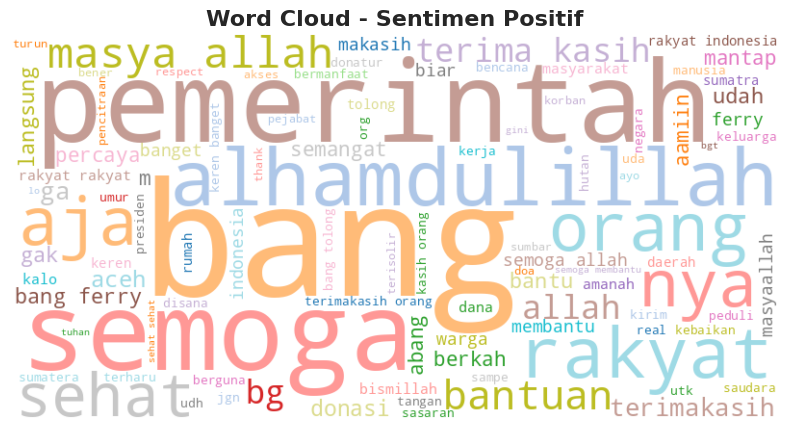

In [73]:
# Buat word cloud untuk masing-masing sentimen
generate_wordcloud(sentimen_Positive, "Word Cloud - Sentimen Positif")

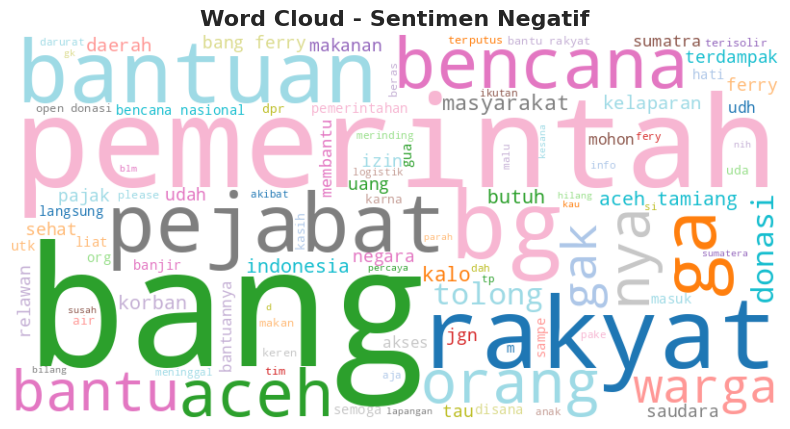

In [74]:
# Buat word cloud untuk masing-masing sentimen
generate_wordcloud(sentimen_Negative, "Word Cloud - Sentimen Negatif")

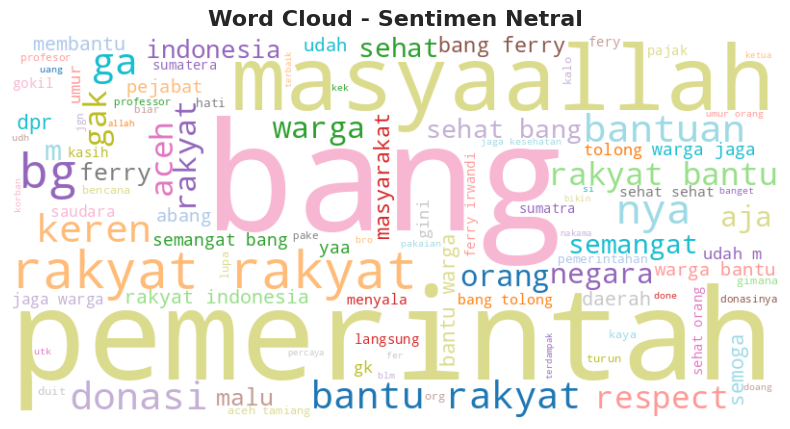

In [75]:
# Buat word cloud untuk masing-masing sentimen
generate_wordcloud(sentimen_Neutral, "Word Cloud - Sentimen Netral")

**FEATURE EXTRACTION**

In [76]:
df_list = df['stemmed_komen'].tolist()
print(df_list)

[nan, nan, 'letsgooo', 'bahan makan berkalikali lipat perintah lambat gerak moga', 'semangat bg', 'rakyat rakyatsemoga lekas baik', 'semangat guys hayu bantu', 'gw liat ad yg donasi juta', 'kalimat aja cania mari bantu biasa bikin lagu cania', 'pasu elite banser mana nihdulu teriak bubarin fpinoh skrg gantiin tugas fpipada sembunyi kmana woii', 'negara andalas keren nama', 'bismillah maaf bang donasi', 'donasi pakai gak', 'tunggu jokes banjir paman', 'bang ferry bantu bener riah aceh gayo lues bang beras mahal banget bahan pangan udah nak beras habis air bersih jarang', 'gass', 'parah dimintain ktp wkwkwk parah asli', 'gimana nasib harimau sumatra ya', 'bg cek dm bg plis', 'terima kasih donatur salam hormat bumi swarna dwipa', 'bantu nyumbang bibit pohon engga', 'cok perintah', 'bpbd himbauan darurat bencana alam jadi', 'yok guys ceban orang mah lebihin dikit k gitu', 'bang prioritas daerah yg sulit jangkau ya minim bantu', 'rakyat perintah', 'top sultan indonesia peduli daerah masyara

In [79]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Isi nilai NaN dengan string kosong
df['stemmed_komen'] = df['stemmed_komen'].fillna('')

# Buat list dari kolom 'steming_data'
df_list = df['stemmed_komen'].tolist()

# Buat objek TfidfVectorizer
df_tfidf = TfidfVectorizer()

# Lakukan transformasi fitur
X = df_tfidf.fit_transform(df_list)

print('Feature Extraction Selesai!!!')
print('===== Bentuk Transformasi Feature Extraction =====')
print(X.shape)

# Dapatkan nama fitur (kata-kata unik)
feature_names = df_tfidf.get_feature_names_out()

# Hitung total skor TF-IDF untuk setiap term (kata)
tfidf_sums = X.sum(axis=0)

# Buat DataFrame untuk menampilkan hasil
tfidf_df = pd.DataFrame({
    'term': feature_names,
    'tfidf_sum': tfidf_sums.tolist()[0]
})

# Urutkan berdasarkan skor TF-IDF terbesar
tfidf_df = tfidf_df.sort_values('tfidf_sum', ascending=False)

print("\n==== Top 20 Terms by Total TF-IDF Score ====")
print(tfidf_df.head(20))

print("\n==== IDF Values ====")
idf_values = df_tfidf.idf_
idf_df = pd.DataFrame({
    'Term': feature_names,
    'IDF': idf_values
})
print(idf_df.head(20))

print("\n==== TF-IDF values for the first 5 documents ====")
for i in range(min(5, len(df_list))):
    first_document_tfidf = pd.DataFrame(
        X[i].T.todense(),
        index=feature_names,
        columns=["TF-IDF"]
    )
    print(f"\nDocument {i+1} TF-IDF Values:")
    print(first_document_tfidf.sort_values("TF-IDF", ascending=False).head(10))

Feature Extraction Selesai!!!
===== Bentuk Transformasi Feature Extraction =====
(3904, 4350)

==== Top 20 Terms by Total TF-IDF Score ====
               term   tfidf_sum
360            bang  165.666051
3197         rakyat  156.570366
3005       perintah  109.764804
2393     masyaallah   94.340668
416           bantu   91.275181
3455          sehat   82.085657
134           allah   69.909453
4323             yg   67.857964
117   alhamdulillah   67.390301
2841          orang   65.449867
4238          warga   61.134882
559              bg   52.852899
4291             ya   51.111853
2528           moga   50.668131
1151          ferry   48.462728
1020         donasi   44.381413
2388          masya   43.629840
1895          keren   42.670327
1547      indonesia   41.890644
2769            nya   39.347816

==== IDF Values ====
            Term       IDF
0          aaaaa  8.576866
1         aamiin  5.804277
2   aamiingausah  8.576866
3    aamiinkalau  8.576866
4             ab  8.576866
5   

In [80]:
y = df['label']
print(y)

0        Netral
1        Netral
2        Netral
3       Positif
4        Netral
         ...   
3899    Negatif
3900    Negatif
3901     Netral
3902     Netral
3903     Netral
Name: label, Length: 3904, dtype: object


In [81]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 19350 stored elements and shape (3904, 4350)>
  Coords	Values
  (2, 2197)	1.0
  (3, 322)	0.3794656352747317
  (3, 2308)	0.3117633354633217
  (3, 538)	0.47722999505131347
  (3, 2225)	0.4013486585135712
  (3, 3005)	0.18630854628306
  (3, 2134)	0.4013486585135712
  (3, 1292)	0.3447332707817708
  (3, 2528)	0.23526069018508147
  (4, 3495)	0.752472400888865
  (4, 559)	0.6586237817605337
  (5, 3197)	0.27545917269375264
  (5, 3201)	0.6929947732396337
  (5, 2182)	0.5301943655991768
  (5, 329)	0.403453123830153
  (6, 3495)	0.3939104578223077
  (6, 1383)	0.5384271190030231
  (6, 1439)	0.6964331195911965
  (6, 416)	0.26440820463215314
  (7, 1387)	0.44158454645344036
  (7, 2209)	0.41868968552992686
  (7, 34)	0.5100393615791264
  (7, 4323)	0.24345759287074567
  (7, 1020)	0.29843925470840676
  (7, 1718)	0.47034487020375854
  :	:
  (3898, 3005)	0.166166531407451
  (3898, 1221)	0.24144507621792727
  (3898, 1738)	0.37454621143112427
  (3898, 

**KLASIFIKASI MODEL MACHINE LEARNING**

In [82]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

Jumlah data training (X_train): 3123
Jumlah data testing (X_test): 781


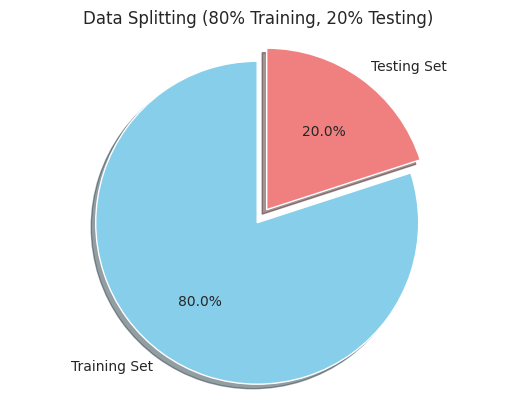

In [83]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting datasets
print("Jumlah data training (X_train):", X_train.shape[0])
print("Jumlah data testing (X_test):", X_test.shape[0])

# Visualize the data split
import matplotlib.pyplot as plt

train_size = X_train.shape[0]
test_size = X_test.shape[0]
total_size = train_size + test_size

labels = ['Training Set', 'Testing Set']
sizes = [train_size, test_size]
colors = ['skyblue', 'lightcoral']
explode = (0.1, 0)  # explode 1st slice

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Data Splitting (80% Training, 20% Testing)')
plt.show()

Sebelum cleaning: 3904
Setelah cleaning: 3240

Training: Logistic Regression
Accuracy: 0.7269
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.76      0.37      0.50       121
      Netral       0.67      0.89      0.76       306
     Positif       0.84      0.70      0.76       221

    accuracy                           0.73       648
   macro avg       0.76      0.65      0.68       648
weighted avg       0.74      0.73      0.71       648



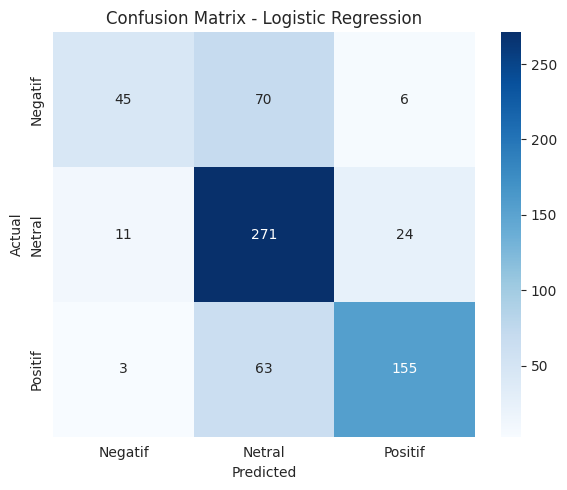


Training: Decision Tree
Accuracy: 0.7099
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.60      0.51      0.55       121
      Netral       0.73      0.77      0.75       306
     Positif       0.73      0.73      0.73       221

    accuracy                           0.71       648
   macro avg       0.69      0.67      0.68       648
weighted avg       0.71      0.71      0.71       648



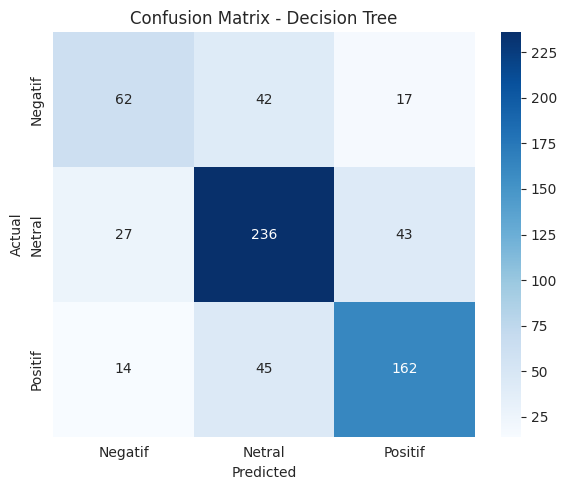


Training: Random Forest
Accuracy: 0.7531
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.79      0.40      0.53       121
      Netral       0.72      0.88      0.79       306
     Positif       0.80      0.78      0.79       221

    accuracy                           0.75       648
   macro avg       0.77      0.68      0.70       648
weighted avg       0.76      0.75      0.74       648



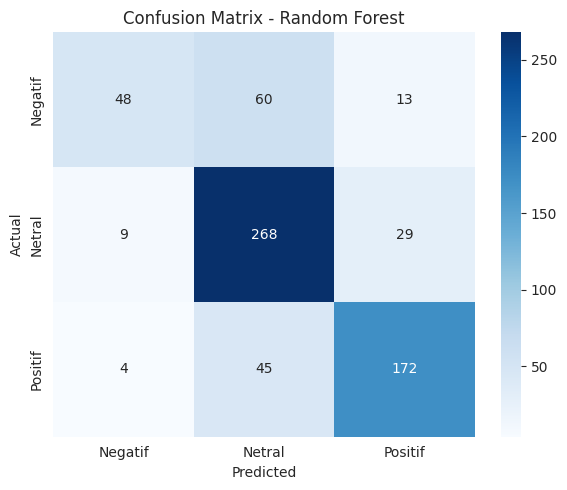


Training: SVM
Accuracy: 0.7623
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.76      0.47      0.58       121
      Netral       0.71      0.89      0.79       306
     Positif       0.87      0.75      0.81       221

    accuracy                           0.76       648
   macro avg       0.78      0.70      0.73       648
weighted avg       0.77      0.76      0.76       648



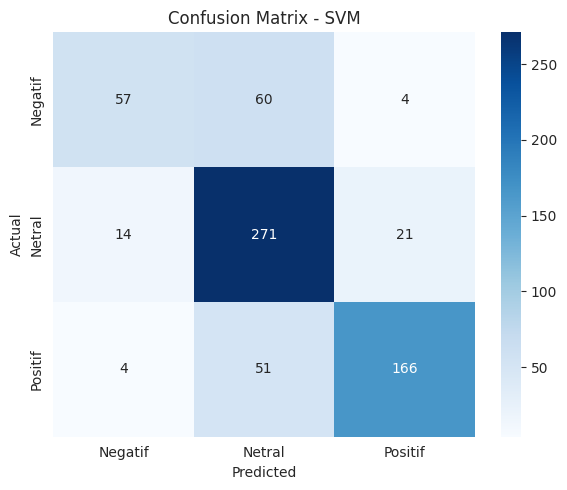


Training: KNN
Accuracy: 0.5741
Classification Report:
              precision    recall  f1-score   support

     Negatif       1.00      0.09      0.17       121
      Netral       0.53      1.00      0.69       306
     Positif       0.98      0.25      0.40       221

    accuracy                           0.57       648
   macro avg       0.84      0.45      0.42       648
weighted avg       0.77      0.57      0.49       648



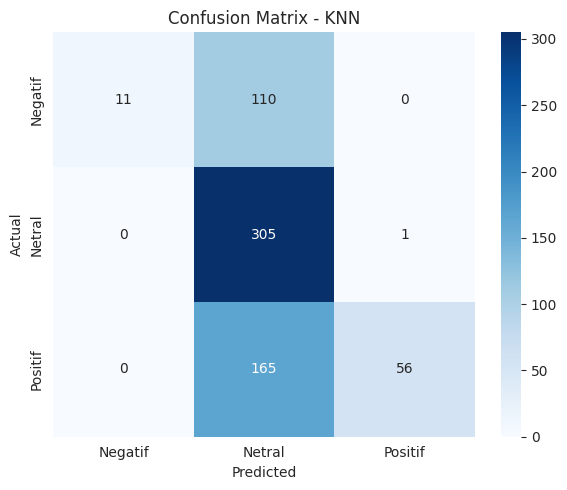


Training: Naive Bayes
Accuracy: 0.6867
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.88      0.17      0.29       121
      Netral       0.63      0.90      0.74       306
     Positif       0.78      0.67      0.73       221

    accuracy                           0.69       648
   macro avg       0.76      0.58      0.59       648
weighted avg       0.73      0.69      0.65       648



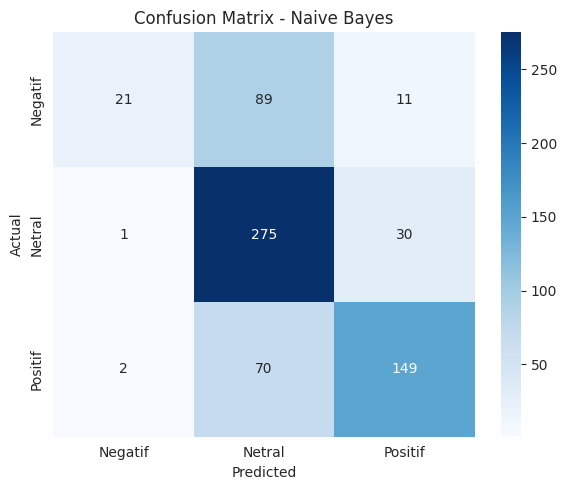


RINGKASAN MODEL
Logistic Regression  | Accuracy: 0.7269
Decision Tree        | Accuracy: 0.7099
Random Forest        | Accuracy: 0.7531
SVM                  | Accuracy: 0.7623
KNN                  | Accuracy: 0.5741
Naive Bayes          | Accuracy: 0.6867


In [88]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Baca data
df = pd.read_csv('labeling_data.csv')

# 2. HAPUS BARIS YANG TIDAK VALID
# Pastikan tidak ada NaN di 'cleaned_komen' atau 'label'
print("Sebelum cleaning:", len(df))
df = df.dropna(subset=['cleaned_komen', 'label'])  # Hapus jika salah satu NaN

# Hapus juga yang string kosong/spasi
df = df[df['cleaned_komen'].str.strip() != '']
print("Setelah cleaning:", len(df))

# 3. Siapkan fitur (X) dan target (y)
X = df['cleaned_komen']
y = df['label']

# 4. Ubah teks jadi vektor numerik
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    lowercase=True,
    ngram_range=(1, 2)  # opsional: tambah bigram
)
X_vec = vectorizer.fit_transform(X)

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42, stratify=y  # stratify untuk distribusi seimbang
)

# 6. Definisikan classifier
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': MultinomialNB()
}

# 7. Train & evaluasi
results = {}
for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print(f"{'='*50}")

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {'accuracy': accuracy, 'report': report, 'cm': cm}

    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(report)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(y_test.unique()),
                yticklabels=sorted(y_test.unique()))
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# 8. Ringkasan
print("\n" + "="*60)
print("RINGKASAN MODEL")
print("="*60)
for name, res in results.items():
    print(f"{name:20} | Accuracy: {res['accuracy']:.4f}")

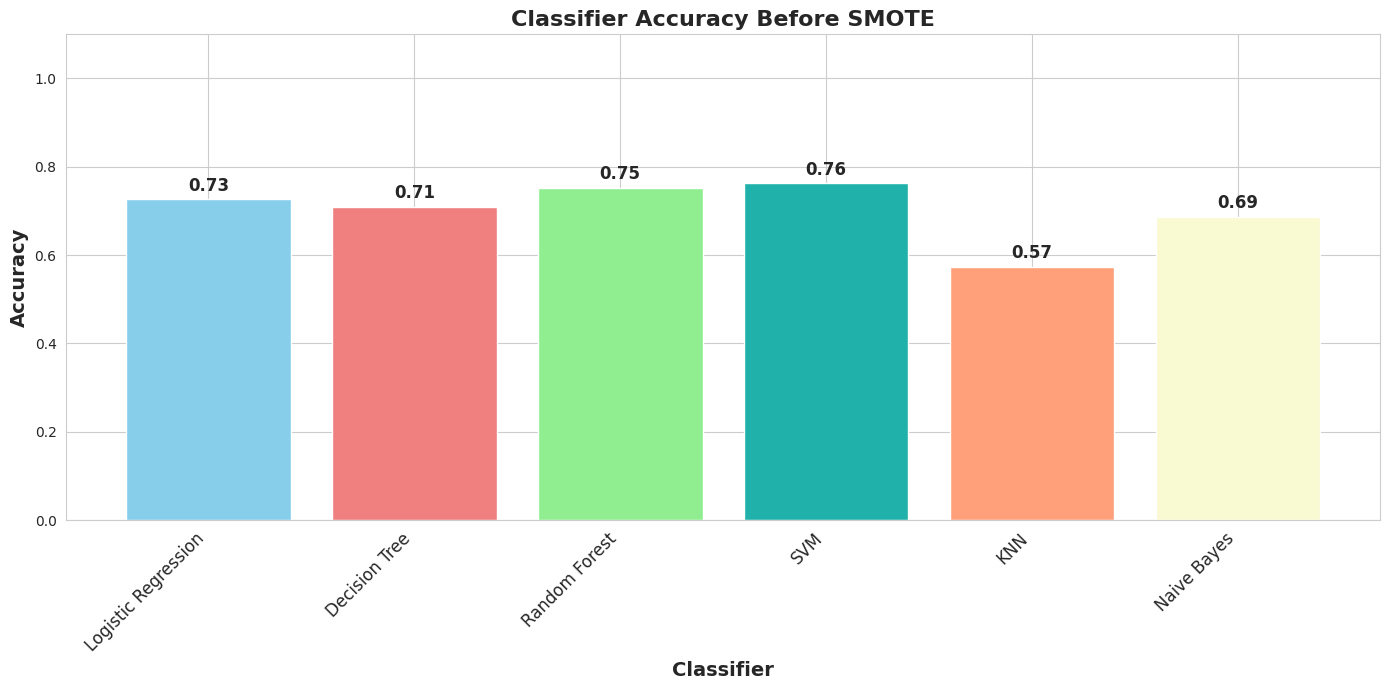

In [89]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assuming 'results' dictionary is defined from previous code
classifiers = list(results.keys())
accuracy_before = [results[name]['accuracy'] for name in classifiers]

# Improved Plotting
plt.figure(figsize=(14, 7))  # Slightly larger figure for better readability
bars = plt.bar(classifiers, accuracy_before, color=['skyblue', 'lightcoral', 'lightgreen', 'lightseagreen', 'lightsalmon', 'lightgoldenrodyellow'])
plt.xlabel("Classifier", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy", fontsize=14, fontweight='bold')
plt.title("Classifier Accuracy Before SMOTE", fontsize=16, fontweight='bold')
plt.ylim(0, 1.1)  # Set y-axis limit
plt.xticks(rotation=45, ha='right', fontsize=12)  # Adjust font size and rotation

# Annotate bars with accuracy values
for bar, acc in zip(bars, accuracy_before):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{acc:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()  # Ensure labels are not cut off
plt.show()